# Stroke Prediction — Machine Learning Project

**Cardiac Patient Monitoring System — AI & Machine Learning Track (Individual Project)**

This notebook applies a complete, curriculum-aligned machine learning workflow to the
**Healthcare Stroke Prediction Dataset**. It follows the pipeline taught in Weeks 1-4 of the
BinX Tech AI & ML Internship Program:

`Python/Jupyter setup → Data Preparation → EDA & Statistics → Supervised Baseline → Model
Comparison → Evaluation (CV, metrics) → Feature Engineering & Pipeline → Unsupervised Analysis`

**Dataset:** `healthcare-dataset-stroke-data.csv`
**Target:** `stroke` (1 = patient had a stroke, 0 = no stroke)



## 1. Environment & Dataset Setup

We start by importing the libraries used throughout the notebook (NumPy, Pandas, Matplotlib,
Seaborn, and Scikit-learn) and loading the dataset into a DataFrame.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Load the dataset
df = pd.read_csv("data/healthcare-dataset-stroke-data.csv")



df = df[df["gender"] != "Other"].reset_index(drop=True)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Inspect Dataset Structure

Before changing anything, we look at the shape, column names, and data types
(`df.shape`, `df.info()`) .

In [4]:
print("Dataset shape:", df.shape)
print()
df.info()

Dataset shape: (5109, 12)

<class 'pandas.DataFrame'>
RangeIndex: 5109 entries, 0 to 5108
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5109 non-null   int64  
 1   gender             5109 non-null   str    
 2   age                5109 non-null   float64
 3   hypertension       5109 non-null   int64  
 4   heart_disease      5109 non-null   int64  
 5   ever_married       5109 non-null   str    
 6   work_type          5109 non-null   str    
 7   Residence_type     5109 non-null   str    
 8   avg_glucose_level  5109 non-null   float64
 9   bmi                4908 non-null   float64
 10  smoking_status     5109 non-null   str    
 11  stroke             5109 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.1 KB


In [5]:
print("Columns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

Columns:
01. id
02. gender
03. age
04. hypertension
05. heart_disease
06. ever_married
07. work_type
08. Residence_type
09. avg_glucose_level
10. bmi
11. smoking_status
12. stroke


## 3. Identify the Target Variable

The target variable for this supervised classification problem is **`stroke`**:
- `1` → the patient had a stroke
- `0` → the patient did not have a stroke

All remaining columns (except the `id` identifier) will be used as input features.

In [6]:
target = "stroke"

print("Target variable:", target)
print("\nUnique values:", sorted(df[target].unique()))
print("\nTarget distribution:")
print(df[target].value_counts())
print()
print(df[target].value_counts(normalize=True).mul(100).round(2).astype(str) + " %")

Target variable: stroke

Unique values: [np.int64(0), np.int64(1)]

Target distribution:
stroke
0    4860
1     249
Name: count, dtype: int64

stroke
0    95.13 %
1     4.87 %
Name: proportion, dtype: str


## 4. Data Dictionary

| Feature | Description | Type |
|---|---|---|
| id | Unique patient identifier | Identifier |
| gender | Patient gender (Male / Female ) | Categorical |
| age | Patient age in years | Numeric |
| hypertension | 1 if the patient has hypertension | Boolean |
| heart_disease | 1 if the patient has a heart disease | Boolean |
| ever_married | Whether the patient has ever been married | Categorical |
| work_type | Type of employment | Categorical |
| Residence_type | Urban or Rural residence | Categorical |
| avg_glucose_level | Average blood glucose level | Numeric |
| bmi | Body mass index | Numeric |
| smoking_status | Smoking history category | Categorical |
| stroke | Whether the patient had a stroke (target) | Target |

`id` is an identifier, not a predictive feature, and will be dropped before modeling.

## 5. Data Preparation — Missing Values

 Pandas workflow (`isnull().sum()`), we count missing values per column
before deciding how to handle them.

In [7]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing (%)": missing_percent
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]
missing_summary

,Missing Values,Missing (%)
bmi,201,3.93


The only column with missing values is **`bmi`** (numeric). Following the "fill with the
median"  (median is more robust to outliers than the mean), we impute the
missing `bmi` values using the column median. We work on a copy (`df_clean`) to keep the raw
dataset untouched.

In [8]:
df_clean = df.copy()

df_clean["bmi"] = df_clean["bmi"].fillna(df_clean["bmi"].median())

print("Remaining missing values:")
remaining = df_clean.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else "None — all missing values handled.")

Remaining missing values:
None — all missing values handled.


## 6. Data Preparation — Duplicate Records

We check for and remove any fully duplicated rows.

In [9]:
duplicate_count = df_clean.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

print(f"Remaining duplicates: {df_clean.duplicated().sum()}")

Duplicate rows found: 0
No duplicate rows found.
Remaining duplicates: 0


## 7. Data Validation — Check for Invalid Values

We check that numeric and categorical values fall inside a logically valid range.

In [10]:
invalid_checks = {
    "age <= 0": (df_clean["age"] <= 0).sum(),
    "avg_glucose_level <= 0": (df_clean["avg_glucose_level"] <= 0).sum(),
    "bmi <= 0": (df_clean["bmi"] <= 0).sum(),
    "gender unexpected values": (~df_clean["gender"].isin(["Male", "Female", "Other"])).sum(),
    "ever_married unexpected values": (~df_clean["ever_married"].isin(["Yes", "No"])).sum(),
    "hypertension outside 0-1": (~df_clean["hypertension"].isin([0, 1])).sum(),
    "heart_disease outside 0-1": (~df_clean["heart_disease"].isin([0, 1])).sum(),
    "stroke outside 0-1": (~df_clean["stroke"].isin([0, 1])).sum(),
}

invalid_summary = pd.DataFrame(
    list(invalid_checks.items()), columns=["Validation Check", "Invalid Count"]
)
invalid_summary["Status"] = invalid_summary["Invalid Count"].apply(
    lambda x: "OK" if x == 0 else "Review"
)
invalid_summary

,Validation Check,Invalid Count,Status
0,age <= 0,0,OK
1,avg_glucose_level <= 0,0,OK
2,bmi <= 0,0,OK
3,gender unexpected values,0,OK
4,ever_married unexpected values,0,OK
5,hypertension outside 0-1,0,OK
6,heart_disease outside 0-1,0,OK
7,stroke outside 0-1,0,OK


All checks pass — no invalid values need correcting for this dataset. The cleaned
DataFrame (`df_clean`) is now ready for exploratory analysis.

## 8. Final Data Quality Summary

In [11]:
print("Cleaned dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Target column:", target, "| Classes:", sorted(df_clean[target].unique()))

Cleaned dataset shape: (5109, 12)
Missing values: 0
Duplicate rows: 0
Target column: stroke | Classes: [np.int64(0), np.int64(1)]


## 9. EDA & Statistics — Descriptive Statistics

Following the  methodology, we compute mean, standard deviation, and quartiles
for every numeric feature to understand center and spread before visualizing.

In [12]:
numeric_features = ["age", "avg_glucose_level", "bmi"]

df_clean[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,5109.0,43.229986,22.613575,0.08,25.00,45.00,61.00,82.00
avg_glucose_level,5109.0,106.140399,45.285004,55.12,77.24,91.88,114.09,271.74
bmi,5109.0,28.863300,7.699785,10.30,23.80,28.10,32.80,97.60


We also compare the **mean vs. median** for each numeric feature —  to decide whether a feature is skewed (mean pulled away from median suggests skew /
outliers).

In [13]:
for col in numeric_features:
    mean_val = df_clean[col].mean()
    median_val = df_clean[col].median()
    std_val = df_clean[col].std()
    print(f"{col:<20} mean={mean_val:7.2f}  median={median_val:7.2f}  std={std_val:7.2f}")

age                  mean=  43.23  median=  45.00  std=  22.61
avg_glucose_level    mean= 106.14  median=  91.88  std=  45.29
bmi                  mean=  28.86  median=  28.10  std=   7.70


## 10. EDA — Target Class Balance

The target `stroke` is heavily **imbalanced**: most patients did not have a stroke. This is
important context for later model evaluation, since accuracy alone would be misleading on
imbalanced data.

In [14]:
target_counts = df_clean[target].value_counts().sort_index()
target_pct = df_clean[target].value_counts(normalize=True).sort_index() * 100

class_balance = pd.DataFrame({
    "Class": target_counts.index,
    "Count": target_counts.values,
    "Percentage": target_pct.values.round(2)
})
class_balance

,Class,Count,Percentage
0,0,4860,95.13
1,1,249,4.87


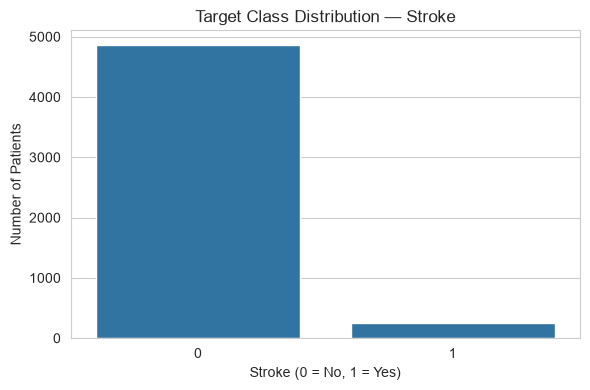

In [49]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x=target)
plt.title("Target Class Distribution — Stroke")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig('outputs/1-Target Class Distribution.png', bbox_inches='tight')

plt.show()

## 11. EDA — Numeric Feature Distributions

Histograms reveal the shape and spread of each numeric features.

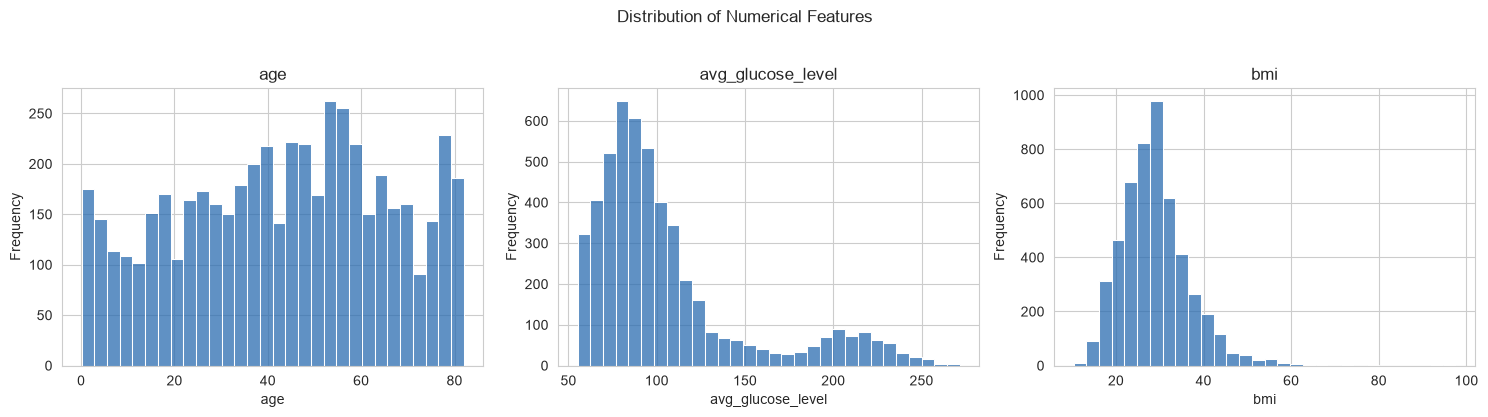

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_features):
    sns.histplot(df_clean[col], bins=30, ax=ax, color="#2b6cb0")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distribution of Numerical Features", y=1.03)
plt.tight_layout()
plt.savefig('outputs/2-Distribution of Numerical Features.png', bbox_inches='tight')

plt.show()

## 12. EDA — Categorical Feature Counts

Count plots show class balance for each categorical feature.

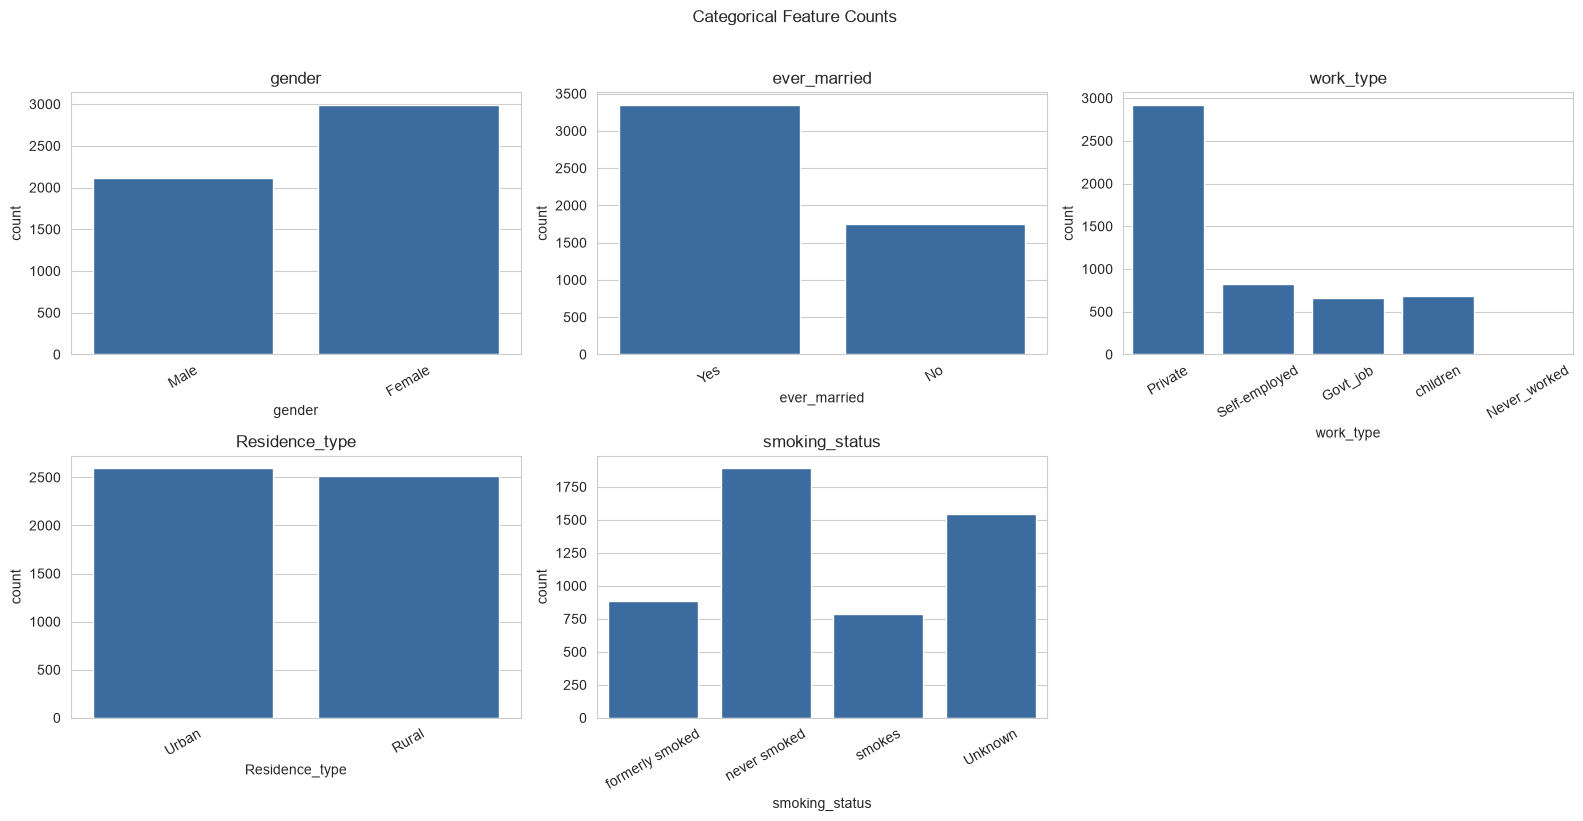

In [51]:
categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features):
    sns.countplot(data=df_clean, x=col, ax=ax, color="#2b6cb0")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)

axes[-1].set_visible(False)
plt.suptitle("Categorical Feature Counts", y=1.02)
plt.tight_layout()
plt.savefig('outputs/3-Categorical Feature Counts.png', bbox_inches='tight')

plt.show()

## 13. EDA — Outlier Detection (Boxplots + IQR)

Boxplots visualize the median, IQR, and points beyond the whiskers. We also
apply the IQR rule in code on `avg_glucose_level`, the feature most likely to contain
clinically meaningful extreme values.

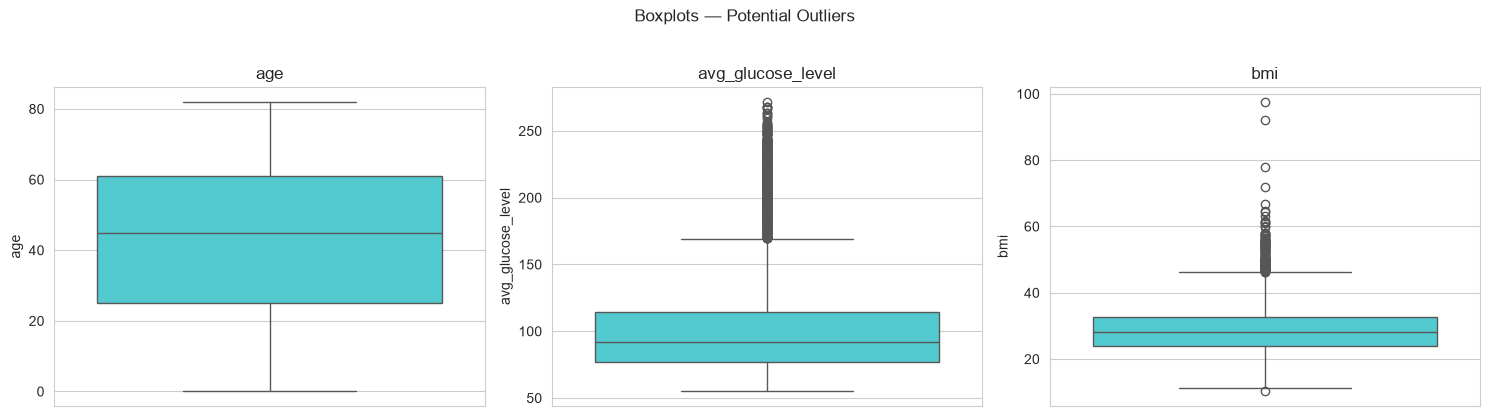

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_features):
    sns.boxplot(y=df_clean[col], ax=ax, color="#3edde5")
    ax.set_title(col)

plt.suptitle("Boxplots — Potential Outliers", y=1.03)
plt.tight_layout()
plt.savefig('outputs/4- Potential Outliers.png', bbox_inches='tight')

plt.show()

In [19]:
col = "avg_glucose_level"
Q1 = df_clean[col].quantile(0.25)
Q3 = df_clean[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]

print(f"{col}: IQR bounds = [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of potential outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}% of rows)")

avg_glucose_level: IQR bounds = [21.96, 169.37]
Number of potential outliers: 627 (12.27% of rows)


These are treated as a *question, not a verdict* : high glucose values are
clinically plausible for stroke patients, so we keep them rather than removing them.

## 14. EDA — Correlation Matrix

A correlation heatmap shows linear relationships between numeric variables and the target.

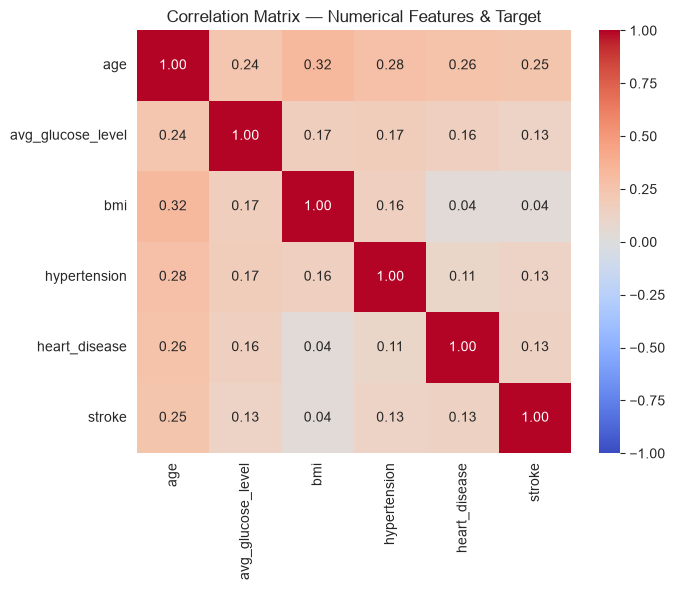

In [54]:
corr_features = numeric_features + ["hypertension", "heart_disease", "stroke"]
corr_matrix = df_clean[corr_features].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix — Numerical Features & Target")
plt.tight_layout()
plt.savefig('outputs/5- Numerical Features & Target.png', bbox_inches='tight')

plt.show()

## 15. EDA — Numeric Features vs. Target

Grouped boxplots compare each numeric feature across stroke / no-stroke patients.

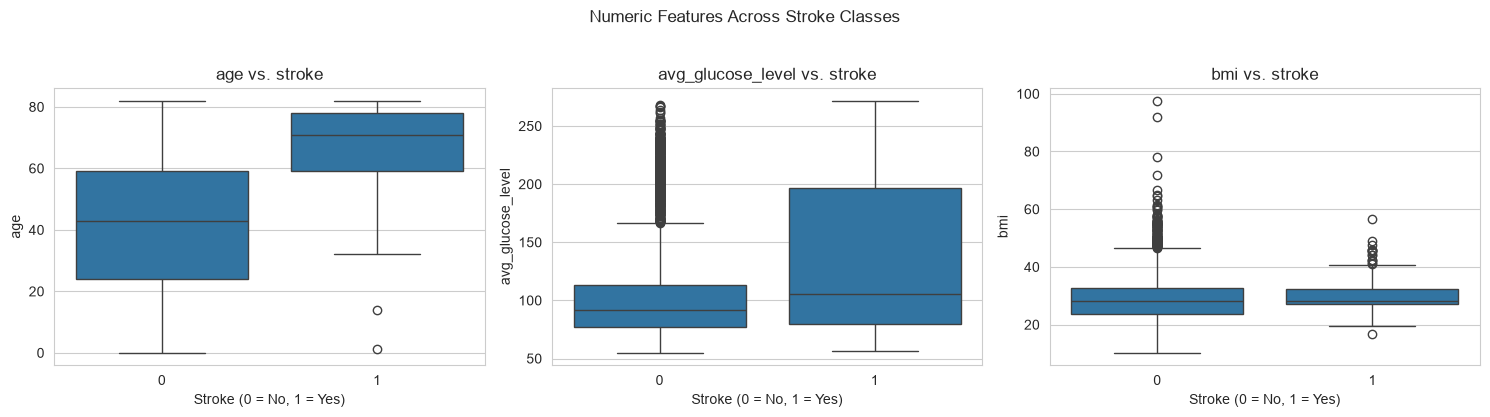

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_features):
    sns.boxplot(data=df_clean, x=target, y=col, ax=ax)
    ax.set_title(f"{col} vs. {target}")
    ax.set_xlabel("Stroke (0 = No, 1 = Yes)")

plt.suptitle("Numeric Features Across Stroke Classes", y=1.03)
plt.tight_layout()
plt.savefig('outputs/6- Numeric Features Across Stroke Classes', bbox_inches='tight')
plt.show()

## 16. EDA — Key Findings

- **Data quality:** only `bmi` had missing values, handled with median imputation; no
  duplicates or invalid values were found.
- **Target imbalance:** stroke patients are a small minority (~5%), so accuracy alone will be a
  misleading metric — precision, recall, F1, and ROC-AUC matter more.
- **Distributions:** `age` and `avg_glucose_level` are the most visibly different features
  between stroke and non-stroke groups; older patients and patients with higher glucose levels
  appear more frequently among stroke cases.
- **Outliers:** high `avg_glucose_level` values exist but are plausible clinical
  measurements, so they are kept rather than removed.

These findings guide the supervised classification setup in the next section.

## 17. Supervised Learning — Classification Problem

**Goal:** predict whether a patient will have a stroke (`stroke` = 1) based on demographic and
clinical features.

- **Features (X):** all columns except `id` and `stroke`
- **Target (y):** `stroke`
- **Baseline model:** Logistic Regression (simple, interpretable)
- **Comparison model:** Random Forest Classifier

### 17.1 Encode Categorical Variables

Scikit-learn models require numeric input, so categorical features are one-hot encoded. We do this with `pd.get_dummies` here for the exploratory
train/test-split models, and later rebuild the same preprocessing inside a leak-free
`Pipeline` + `ColumnTransformer` .

In [22]:
df_model = df_clean.drop(columns=["id"]).copy()

df_encoded = pd.get_dummies(
    df_model,
    columns=["gender", "ever_married", "work_type", "Residence_type", "smoking_status"],
    drop_first=True
)

df_encoded.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,True,False,False,True,False,False,False,True,False


### 17.2 Features & Target Separation

In [23]:
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target classes:", sorted(y.unique()))

X shape: (5109, 15)
y shape: (5109,)
Target classes: [np.int64(0), np.int64(1)]


### 17.3 Train / Test Split

An 80/20 split with a fixed `random_state`  and `stratify=y`,since the target is imbalanced.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 4087
Test samples: 1022


## 18. Baseline Model — Logistic Regression

Logistic Regression is trained inside a small pipeline with `StandardScaler`, following the pattern (scale numeric features, then fit).

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"))
])

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Logistic Regression baseline accuracy: {baseline_accuracy:.2%}")

Logistic Regression baseline accuracy: 73.87%


## 19. Model Comparison — Random Forest

A Random Forest is trained on the **same** train/test split so the comparison is fair.

In [26]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced"
)
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest accuracy: {rf_accuracy:.2%}")

Random Forest accuracy: 94.23%


## 20. Model Evaluation — Cross-Validation

Instead of trusting a single split, we use 5-fold **stratified** cross-validation so the class imbalance is preserved in every fold.

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_cv_scores = cross_val_score(baseline_model, X_train, y_train, cv=cv, scoring="f1")
rf_cv_scores = cross_val_score(random_forest, X_train, y_train, cv=cv, scoring="f1")

print("Logistic Regression — F1 per fold:", np.round(lr_cv_scores, 3))
print(f"Logistic Regression — mean F1: {lr_cv_scores.mean():.3f}  (std {lr_cv_scores.std():.3f})")
print()
print("Random Forest — F1 per fold:", np.round(rf_cv_scores, 3))
print(f"Random Forest — mean F1: {rf_cv_scores.mean():.3f}  (std {rf_cv_scores.std():.3f})")

Logistic Regression — F1 per fold: [0.241 0.268 0.244 0.218 0.22 ]
Logistic Regression — mean F1: 0.238  (std 0.018)

Random Forest — F1 per fold: [0.098 0.039 0.034 0.136 0.107]
Random Forest — mean F1: 0.083  (std 0.040)


We use **F1-score** rather than accuracy for cross-validation scoring, since accuracy is
misleading on this imbalanced target .

## 21. Model Evaluation — Confusion Matrix

The confusion matrix breaks predictions into True/False Positives/Negatives.

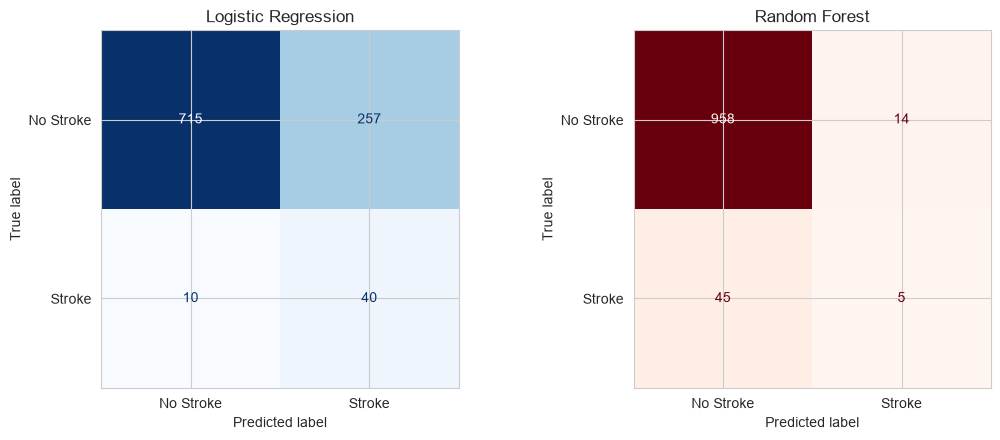

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_lr = confusion_matrix(y_test, y_pred_baseline)
cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(cm_lr, display_labels=["No Stroke", "Stroke"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(cm_rf, display_labels=["No Stroke", "Stroke"]).plot(ax=axes[1], cmap="Reds", colorbar=False)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.savefig('outputs/7- Model Evaluation', bbox_inches='tight')
plt.show()

## 22. Model Evaluation — Precision, Recall & F1-Score

- **Precision:** of everything predicted as stroke, how much was right?
- **Recall:** of all actual stroke cases, how many did the model catch?
- **F1-score:** balanced combination of the two.

For stroke screening, **recall matters most** — missing an actual stroke case (a false
negative) is more costly than a false alarm.

In [29]:
from sklearn.metrics import classification_report

lr_report = classification_report(y_test, y_pred_baseline, output_dict=True, zero_division=0)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True, zero_division=0)

metrics_comparison = pd.DataFrame({
    "Metric": ["Precision (stroke)", "Recall (stroke)", "F1-score (stroke)"],
    "Logistic Regression": [
        lr_report["1"]["precision"], lr_report["1"]["recall"], lr_report["1"]["f1-score"]
    ],
    "Random Forest": [
        rf_report["1"]["precision"], rf_report["1"]["recall"], rf_report["1"]["f1-score"]
    ]
})

metrics_comparison.style.format({"Logistic Regression": "{:.2%}", "Random Forest": "{:.2%}"})

,Metric,Logistic Regression,Random Forest
0,Precision (stroke),13.47%,26.32%
1,Recall (stroke),80.00%,10.00%
2,F1-score (stroke),23.05%,14.49%


## 23. Model Evaluation — ROC-AUC

ROC-AUC summarizes how well the model separates the two classes across every threshold
, independent of any single decision cutoff.

In [30]:
from sklearn.metrics import roc_auc_score, roc_curve

lr_proba = baseline_model.predict_proba(X_test)[:, 1]
rf_proba = random_forest.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, lr_proba)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Logistic Regression ROC-AUC: {lr_auc:.3f}")
print(f"Random Forest ROC-AUC:       {rf_auc:.3f}")

Logistic Regression ROC-AUC: 0.840
Random Forest ROC-AUC:       0.794


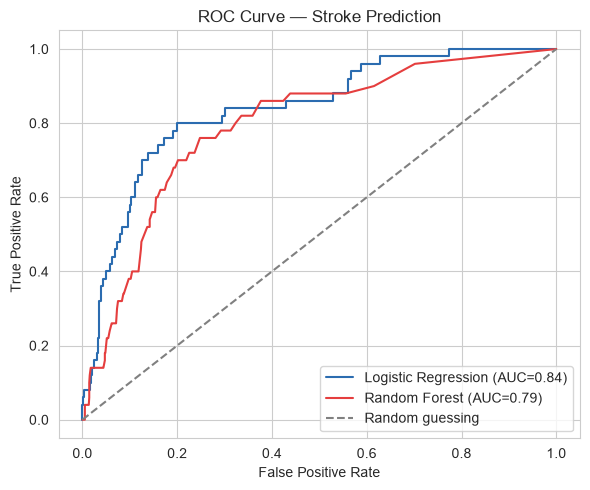

In [57]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={lr_auc:.2f})", color="#2b6cb0")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.2f})", color="#e53e3e")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Stroke Prediction")
plt.legend()
plt.tight_layout()
plt.savefig('outputs/8- Model Evaluation ROC Curve Stroke Prediction', bbox_inches='tight')
plt.show()

## 24. Model Comparison — Final Summary Table

In [32]:
model_comparison = pd.DataFrame({
    "Metric": ["Test Accuracy", "CV F1 (mean)", "Precision (stroke)", "Recall (stroke)",
               "F1-score (stroke)", "ROC-AUC"],
    "Logistic Regression": [
        baseline_accuracy, lr_cv_scores.mean(),
        lr_report["1"]["precision"], lr_report["1"]["recall"], lr_report["1"]["f1-score"], lr_auc
    ],
    "Random Forest": [
        rf_accuracy, rf_cv_scores.mean(),
        rf_report["1"]["precision"], rf_report["1"]["recall"], rf_report["1"]["f1-score"], rf_auc
    ]
})

model_comparison.style.format({"Logistic Regression": "{:.2%}", "Random Forest": "{:.2%}"})

,Metric,Logistic Regression,Random Forest
0,Test Accuracy,73.87%,94.23%
1,CV F1 (mean),23.81%,8.28%
2,Precision (stroke),13.47%,26.32%
3,Recall (stroke),80.00%,10.00%
4,F1-score (stroke),23.05%,14.49%
5,ROC-AUC,83.95%,79.39%


**False positives** here mean predicting stroke for a patient who did not have one;
**false negatives** mean missing an actual stroke case. Given the class imbalance, both models
achieve high accuracy mostly by predicting the majority class well — recall on the stroke
class is the metric that best reflects real screening usefulness.

## 25. Bias-Variance Check

Comparing the training score to the cross-validated score helps diagnose overfitting or
underfitting.

In [33]:
from sklearn.metrics import f1_score

train_f1_lr = f1_score(y_train, baseline_model.predict(X_train))
train_f1_rf = f1_score(y_train, random_forest.predict(X_train))

print(f"Logistic Regression — Train F1: {train_f1_lr:.3f} | CV F1: {lr_cv_scores.mean():.3f}")
print(f"Random Forest       — Train F1: {train_f1_rf:.3f} | CV F1: {rf_cv_scores.mean():.3f}")

Logistic Regression — Train F1: 0.235 | CV F1: 0.238
Random Forest       — Train F1: 0.997 | CV F1: 0.083


The Random Forest's training F1 is noticeably higher than its cross-validated F1 — a sign
of some overfitting (high variance), consistent with the diagnosis table (large
train-vs-validation gap = overfitting). Logistic Regression's smaller gap suggests it
generalizes more consistently, even though its raw scores are close to the Random Forest's.

## 26. Feature Engineering & Pipeline

### 26.1 Engineer a New Feature

We create `glucose_per_age`, representing average glucose level relative to age — a feature
combining two of the strongest individual signals for stroke risk .

In [34]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

X_train_fe["glucose_per_age"] = X_train_fe["avg_glucose_level"] / X_train_fe["age"].replace(0, np.nan)
X_test_fe["glucose_per_age"] = X_test_fe["avg_glucose_level"] / X_test_fe["age"].replace(0, np.nan)

X_train_fe["glucose_per_age"] = X_train_fe["glucose_per_age"].fillna(X_train_fe["glucose_per_age"].median())
X_test_fe["glucose_per_age"] = X_test_fe["glucose_per_age"].fillna(X_train_fe["glucose_per_age"].median())

print("Training features:", X_train_fe.shape[1])
print("Test features:", X_test_fe.shape[1])
X_train_fe[["age", "avg_glucose_level", "glucose_per_age"]].head()

Training features: 16
Test features: 16


,age,avg_glucose_level,glucose_per_age
845,48.0,69.21,1.441875
3744,29.0,84.19,2.903103
4183,35.0,119.40,3.411429
3409,38.0,108.68,2.860000
284,14.0,82.34,5.881429


### 26.2 Build a Leak-Free Pipeline

We rebuild preprocessing from the raw cleaned columns (not the earlier `pd.get_dummies`
version) so that a `ColumnTransformer` scales numeric columns and one-hot encodes categorical
columns **inside** the pipeline — this guarantees the scaler/encoder is fit on training data
only, avoiding data leakage.

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Rebuild train/test features from the cleaned (non-encoded) dataframe
X_raw = df_model.drop(columns=[target]).copy()
y_raw = df_model[target]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=RANDOM_STATE, stratify=y_raw
)

# Add the engineered feature to the raw split too
X_train_raw = X_train_raw.copy()
X_test_raw = X_test_raw.copy()
X_train_raw["glucose_per_age"] = X_train_raw["avg_glucose_level"] / X_train_raw["age"].replace(0, np.nan)
X_test_raw["glucose_per_age"] = X_test_raw["avg_glucose_level"] / X_test_raw["age"].replace(0, np.nan)
X_train_raw["glucose_per_age"] = X_train_raw["glucose_per_age"].fillna(X_train_raw["glucose_per_age"].median())
X_test_raw["glucose_per_age"] = X_test_raw["glucose_per_age"].fillna(X_train_raw["glucose_per_age"].median())

numeric_cols = ["age", "avg_glucose_level", "bmi", "glucose_per_age"]
categorical_cols = ["gender", "hypertension", "heart_disease", "ever_married",
                     "work_type", "Residence_type", "smoking_status"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"))
])

pipeline.fit(X_train_raw, y_train_raw)
pipeline_preds = pipeline.predict(X_test_raw)
pipeline_accuracy = accuracy_score(y_test_raw, pipeline_preds)

print(f"Pipeline test accuracy: {pipeline_accuracy:.2%}")

Pipeline test accuracy: 73.78%


### 26.3 Hyperparameter Tuning — GridSearchCV

We tune the pipeline's Logistic Regression regularization strength `C` with `GridSearchCV`
and 5-fold cross-validation, scoring on F1 .

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
}

grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring="f1")
grid.fit(X_train_raw, y_train_raw)

print("Best parameters:", grid.best_params_)
print(f"Best cross-validated F1: {grid.best_score_:.3f}")

best_pipeline = grid.best_estimator_
tuned_preds = best_pipeline.predict(X_test_raw)
tuned_f1 = f1_score(y_test_raw, tuned_preds)
print(f"Tuned pipeline test F1: {tuned_f1:.3f} (untuned baseline F1: {lr_report['1']['f1-score']:.3f})")

Best parameters: {'model__C': 10}
Best cross-validated F1: 0.238
Tuned pipeline test F1: 0.230 (untuned baseline F1: 0.231)


### 26.4 Reproducibility Check

Re-running the pipeline from scratch confirms the workflow is fully reproducible end to end.

In [37]:
pipeline_rerun = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                  C=grid.best_params_["model__C"], class_weight="balanced"))
])
pipeline_rerun.fit(X_train_raw, y_train_raw)
rerun_preds = pipeline_rerun.predict(X_test_raw)

print("Rerun test accuracy:", f"{accuracy_score(y_test_raw, rerun_preds):.2%}")
print("Predictions match test set size:", len(rerun_preds) == len(y_test_raw))

Rerun test accuracy: 73.78%
Predictions match test set size: True


## 27. Unsupervised Analysis — Clustering & PCA

The project guide requires an unsupervised section using clustering and/or dimensionality
reduction to explore patient groups. We apply **PCA** to reduce the numeric features to two
components for visualization, then run **K-Means** clustering to look for natural patient
groupings, independent of the `stroke` label.

In [38]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Use the scaled numeric features only for this unsupervised exploration
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(df_clean[numeric_features])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_components = pca.fit_transform(X_numeric_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Total variance explained by 2 components:", pca.explained_variance_ratio_.sum().round(3))

Explained variance ratio: [0.497 0.281]
Total variance explained by 2 components: 0.779


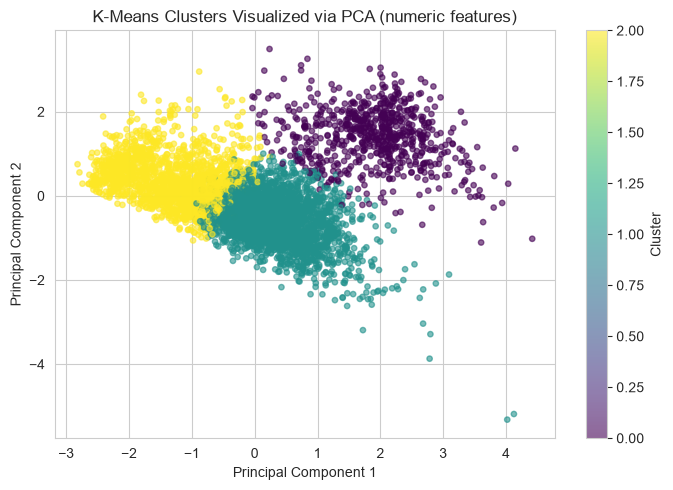

In [58]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_numeric_scaled)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(pca_components[:, 0], pca_components[:, 1], c=clusters, cmap="viridis", alpha=0.6, s=15)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized via PCA (numeric features)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig('outputs/9- MK-Means Clusters Visualized via PCA (numeric features)', bbox_inches='tight')
plt.show()

In [40]:
# Compare cluster composition with actual stroke rate
cluster_summary = df_clean.copy()
cluster_summary["cluster"] = clusters

cluster_summary.groupby("cluster")[["age", "avg_glucose_level", "bmi", "stroke"]].mean().round(2)

,age,avg_glucose_level,bmi,stroke
cluster,,,,
0,60.43,205.19,32.89,0.13
1,54.33,89.00,31.68,0.06
2,19.00,92.69,22.86,0.00


**Interpretation:** the clusters mostly separate patients by age and glucose level, and the
cluster with the oldest, highest-glucose patients also shows the highest stroke rate — matching
the correlation and bivariate findings from the EDA section. This is exploratory pattern-finding,
not a diagnostic tool.

## 28. Final Project Summary

**Data Preparation:** missing `bmi` values were imputed with the median; no duplicates or
invalid values were found in the dataset.

**EDA:** the target is heavily imbalanced (~5% stroke cases); age and average glucose level
show the clearest separation between stroke and non-stroke patients.

**Modeling:** Logistic Regression was used as the baseline classifier, compared against a
Random Forest on the same train/test split.

**Evaluation:** models were compared using cross-validated F1, precision, recall, F1-score,
ROC-AUC, and confusion matrices — with recall on the stroke class treated as the most
clinically relevant metric given the imbalance.

**Feature Engineering & Pipeline:** an engineered `glucose_per_age` feature and a leak-free
`ColumnTransformer` + `Pipeline` were built and tuned with `GridSearchCV`.

**Unsupervised Analysis:** PCA + K-Means clustering explored natural patient groupings,
showing that older, higher-glucose clusters align with higher observed stroke rates.

> ⚠️ This project is for educational purposes only and is not intended for clinical diagnosis
> or medical decision-making.